In [1]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

c:\Users\AT\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Download latest version
path = kagglehub.dataset_download("paresh2047/uci-semcom")
print("Path to dataset files:", path)

ConnectionError: HTTPSConnectionPool(host='api.kaggle.com', port=443): Max retries exceeded with url: /v1/datasets.DatasetApiService/GetDataset (Caused by NameResolutionError("HTTPSConnection(host='api.kaggle.com', port=443): Failed to resolve 'api.kaggle.com' ([Errno 11001] getaddrinfo failed)"))

In [ ]:
csv_path = os.path.join(path, "uci-secom.csv")
df = pd.read_csv(csv_path)

In [ ]:
df.shape
df.head()  # numbers is the label column, and the rest are features. The label is -1 for pass and 1 for fail

,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


In [ ]:
df.describe()  # check for missing values

,0,1,2,3,4,5,6,7,8,9,...,581,582,583,584,585,586,587,588,589,Pass/Fail
count,1561.000000,1560.000000,1553.000000,1553.000000,1553.000000,1553.0,1553.000000,1558.000000,1565.000000,1565.000000,...,618.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1567.000000
mean,3014.452896,2495.850231,2200.547318,1396.376627,4.197013,100.0,101.112908,0.121822,1.462862,-0.000841,...,97.934373,0.500096,0.015318,0.003847,3.067826,0.021458,0.016475,0.005283,99.670066,-0.867262
std,73.621787,80.407705,29.513152,441.691640,56.355540,0.0,6.237214,0.008961,0.073897,0.015116,...,87.520966,0.003404,0.017180,0.003720,3.578033,0.012358,0.008808,0.002867,93.891919,0.498010
min,2743.240000,2158.750000,2060.660000,0.000000,0.681500,100.0,82.131100,0.000000,1.191000,-0.053400,...,0.000000,0.477800,0.006000,0.001700,1.197500,-0.016900,0.003200,0.001000,0.000000,-1.000000
25%,2966.260000,2452.247500,2181.044400,1081.875800,1.017700,100.0,97.920000,0.121100,1.411200,-0.010800,...,46.184900,0.497900,0.011600,0.003100,2.306500,0.013425,0.010600,0.003300,44.368600,-1.000000
50%,3011.490000,2499.405000,2201.066700,1285.214400,1.316800,100.0,101.512200,0.122400,1.461600,-0.001300,...,72.288900,0.500200,0.013800,0.003600,2.757650,0.020500,0.014800,0.004600,71.900500,-1.000000
75%,3056.650000,2538.822500,2218.055500,1591.223500,1.525700,100.0,104.586700,0.123800,1.516900,0.008400,...,116.539150,0.502375,0.016500,0.004100,3.295175,0.027600,0.020300,0.006400,114.749700,-1.000000
max,3356.350000,2846.440000,2315.266700,3715.041700,1114.536600,100.0,129.252200,0.128600,1.656400,0.074900,...,737.304800,0.509800,0.476600,0.104500,99.303200,0.102800,0.079900,0.028600,737.304800,1.000000


In [ ]:
df.info()    
df.dtypes.value_counts()   # number of coloumn to each data type 

<class 'pandas.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 592 entries, Time to Pass/Fail
dtypes: float64(590), int64(1), str(1)
memory usage: 7.1 MB


float64    590
str          1
int64        1
Name: count, dtype: int64

In [ ]:
df.duplicated().sum() # to check if there are any duplicate rows in the dataset

np.int64(0)

In [ ]:
missing_values = df.isnull().sum()  # count of missing values in each column
print("Missing values in each column:\n", missing_values)


Missing values in each column:
 Time          0
0             6
1             7
2            14
3            14
             ..
586           1
587           1
588           1
589           1
Pass/Fail     0
Length: 592, dtype: int64


In [ ]:
missing_values_percentage = df.isnull().mean() * 100  # percentage of missing values in each column
missing_values_percentage.sort_values(ascending=False).head(20)

293    91.193363
292    91.193363
157    91.193363
158    91.193363
492    85.577537
220    85.577537
85     85.577537
358    85.577537
518    64.964901
382    64.964901
245    64.964901
244    64.964901
383    64.964901
384    64.964901
246    64.964901
517    64.964901
110    64.964901
109    64.964901
516    64.964901
111    64.964901
dtype: float64

In [ ]:
target = df['Pass/Fail'].value_counts() # number of pass and fail samples
print ("Number of pass and fail samples:\n", target)
target_percentage = df['Pass/Fail'].value_counts(normalize=True) * 100   # percentage of pass and fail samples
print ("Percentage of pass and fail samples:\n", target_percentage)

Number of pass and fail samples:
 Pass/Fail
-1    1463
 1     104
Name: count, dtype: int64
Percentage of pass and fail samples:
 Pass/Fail
-1    93.363114
 1     6.636886
Name: proportion, dtype: float64


In [ ]:
# Column with missing values > 50 don't add any value to the model so we will drop it 
missing_values = df.isnull().mean() * 100
high_missing_columns = missing_values[missing_values > 50].index
df = df.drop(columns=high_missing_columns) # Drop the column with missing values > 50 
print(df.shape) # Before : 592 column , After : 564

(1567, 564)


In [ ]:
# Drop the column which is zero variance 
variances = df.drop(columns=['Time', 'Pass/Fail']).var() 
zero_var_cols = variances[variances == 0].index
df = df.drop(columns=zero_var_cols) # 116 column will be droped 
print(df.shape) # Before : 564 , After = 448 

(1567, 448)


In [ ]:
from sklearn.impute import SimpleImputer # import this library for filling the missing values 

feature_cols = [c for c in df.columns if c not in ('Time', 'Pass/Fail')] # loop to make the column in list except the (time - pass/fail) 
imputer = SimpleImputer(strategy='median') # filling the missing values by median 
df[feature_cols] = imputer.fit_transform(df[feature_cols]) #replace the old column (with missing values) by the new one (by filling it) in new array 

In [ ]:
df.isnull().sum()

Time         0
0            0
1            0
2            0
3            0
            ..
586          0
587          0
588          0
589          0
Pass/Fail    0
Length: 448, dtype: int64

In [ ]:
feature_columns  = [c for c in df.columns if c not in ('Time', 'Pass/Fail')]
X = df[feature_columns]       # All sensors after Cleaning as the features 
y = df['Pass/Fail']        # The Output ( target ) that will be Predicted 

In [ ]:
from sklearn.model_selection import train_test_split
# To devide the data to 80 % train and 20% test 
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)
 # stratify=y to keep the same ratio of pass/fail in both train and test set
 # in train : 1170 pass and  117 fail , in test 293 pass and 29 fail

In [ ]:
from sklearn.preprocessing import StandardScaler
# there are many sensors with different scale, so we will scale the data to have mean=0 and std=1  (standardization the data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) 


In [ ]:
# class weight 
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(class_weight='balanced')

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

In [ ]:
# unique_vals = df['Pass/Fail'].unique()  # [0, 1, 2]
# targets = [df.loc[df['Pass/Fail'] == val] for val in unique_vals]

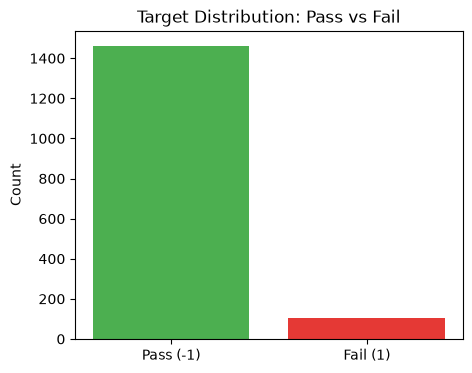

In [ ]:
# to show the imbalance without reading all coloumn of thre target
plt.figure(figsize=(5,4))
counts = df['Pass/Fail'].value_counts().sort_index()
plt.bar(['Pass (-1)', 'Fail (1)'], [counts[-1], counts[1]], color=['#4CAF50', '#E53935'])
plt.title('Target Distribution: Pass vs Fail')
plt.ylabel('Count')
plt.show()

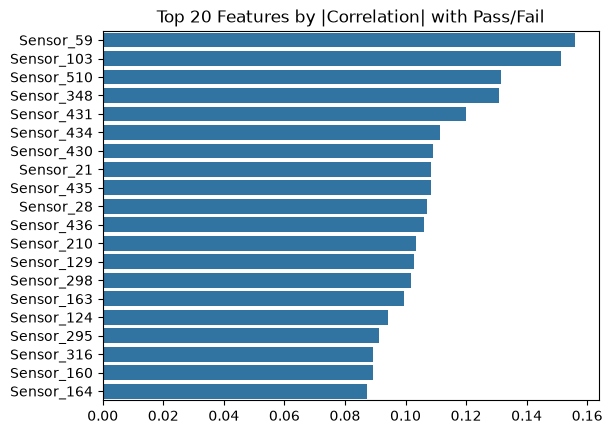

In [ ]:
# To define which coloumn related to fail the wafer 
corrs = df[feature_cols].corrwith(df['Pass/Fail']).abs().sort_values(ascending=False).head(20)
sns.barplot(x=corrs.values, y=[f"Sensor_{c}" for c in corrs.index])
plt.title('Top 20 Features by |Correlation| with Pass/Fail')
plt.show()

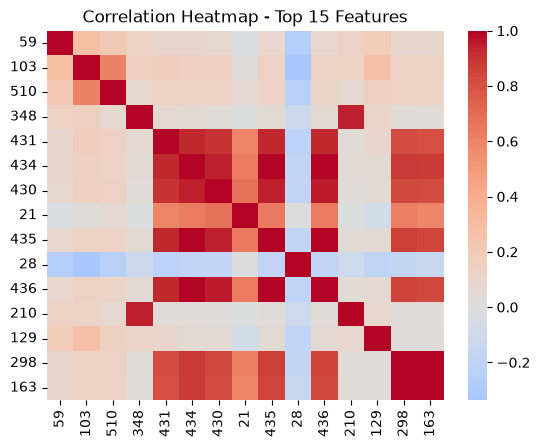

In [ ]:
# to show the relation between the sensors by heatmap graph 
top15 = corrs.head(15).index.tolist()
corr_matrix = df[top15].corr()
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - Top 15 Features')
plt.show()

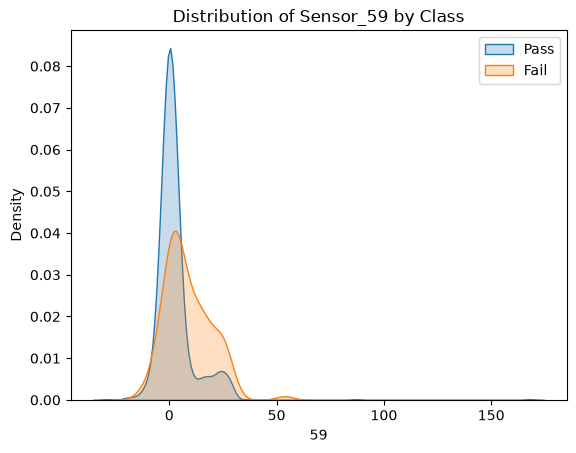

In [ ]:
top_feat = corrs.index[0]   # sensor_59 because  it is the high correlation by pass/fail 
sns.kdeplot(df[df['Pass/Fail']==-1][top_feat], label='Pass', fill=True)
sns.kdeplot(df[df['Pass/Fail']==1][top_feat], label='Fail', fill=True)
plt.title(f'Distribution of Sensor_{top_feat} by Class')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

for name, model in models.items():
    preds = model.predict(X_test_scaled)
    probs = model.predict_proba(X_test_scaled)[:,1]
    
    print(name)
    print("Precision (Fail):", precision_score(y_test, preds, pos_label=1))
    print("Recall (Fail):", recall_score(y_test, preds, pos_label=1))
    print("F1 (Fail):", f1_score(y_test, preds, pos_label=1))
    print("ROC-AUC:", roc_auc_score(y_test, probs))
    print(confusion_matrix(y_test, preds))

Logistic Regression
Precision (Fail): 0.10526315789473684
Recall (Fail): 0.19047619047619047
F1 (Fail): 0.13559322033898305
ROC-AUC: 0.6208353648626687
[[259  34]
 [ 17   4]]
Random Forest
Precision (Fail): 0.0
Recall (Fail): 0.0
F1 (Fail): 0.0
ROC-AUC: 0.7801885259223142
[[292   1]
 [ 21   0]]
SVM
Precision (Fail): 0.5
Recall (Fail): 0.047619047619047616
F1 (Fail): 0.08695652173913043
ROC-AUC: 0.6535023565740288
[[292   1]
 [ 20   1]]


In [ ]:
# Logistic Regrssion Model 

# version1 : class weight 
model_cw = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)
model_cw.fit(X_train_scaled, y_train)

# version 2 : SMOTE 
model_smote = LogisticRegression(max_iter=2000, random_state=42)
model_smote.fit(X_train_balanced, y_train_balanced)

# Compare between the 2 versions 
from sklearn.metrics import f1_score, recall_score

preds_cw = model_cw.predict(X_test_scaled)
preds_smote = model_smote.predict(X_test_scaled)

print("class_weight -> F1:", f1_score(y_test, preds_cw, pos_label=1), "| Recall:", recall_score(y_test, preds_cw, pos_label=1))
print("SMOTE        -> F1:", f1_score(y_test, preds_smote, pos_label=1), "| Recall:", recall_score(y_test, preds_smote, pos_label=1))

class_weight -> F1: 0.13559322033898305 | Recall: 0.19047619047619047
SMOTE        -> F1: 0.1016949152542373 | Recall: 0.14285714285714285


In [ ]:
#  Random Forestn Model 

from sklearn.ensemble import RandomForestClassifier

# version1 : class weight 
model_rf_cw = RandomForestClassifier(class_weight='balanced', n_estimators=300, random_state=42)
model_rf_cw.fit(X_train_scaled, y_train)

# version 2  : SMOTE 
model_rf_smote = RandomForestClassifier(n_estimators=300, random_state=42)
model_rf_smote.fit(X_train_balanced, y_train_balanced)
# compeare between the 2 versions 
preds_rf_cw = model_rf_cw.predict(X_test_scaled)
preds_rf_smote = model_rf_smote.predict(X_test_scaled)

print("RF class_weight -> F1:", f1_score(y_test, preds_rf_cw, pos_label=1), "| Recall:", recall_score(y_test, preds_rf_cw, pos_label=1))
print("RF SMOTE        -> F1:", f1_score(y_test, preds_rf_smote, pos_label=1), "| Recall:", recall_score(y_test, preds_rf_smote, pos_label=1))

RF class_weight -> F1: 0.0 | Recall: 0.0
RF SMOTE        -> F1: 0.0 | Recall: 0.0


In [ ]:
probs_rf = model_rf_smote.predict_proba(X_test_scaled)[:,1]
# changing the Threshold to show the best result of RF model by trying (0.1 , 0.2 , 0.3)
threshold = 0.2
preds_rf_adjusted = (probs_rf >= threshold).astype(int)
preds_rf_adjusted = pd.Series(preds_rf_adjusted).map({1: 1, 0: -1})  

print("RF (threshold=0.2) -> F1:", f1_score(y_test, preds_rf_adjusted, pos_label=1), 
      "| Recall:", recall_score(y_test, preds_rf_adjusted, pos_label=1))

RF (threshold=0.2) -> F1: 0.26666666666666666 | Recall: 0.7619047619047619


In [ ]:
# SVM model 
from sklearn.svm import SVC

# version1 : class weight 
model_svm_cw = SVC(class_weight='balanced', probability=True, random_state=42)
model_svm_cw.fit(X_train_scaled, y_train)

# version 2  : SMOTE 
model_svm_smote = SVC(probability=True, random_state=42)
model_svm_smote.fit(X_train_balanced, y_train_balanced)

# compeare between the 2 versions 
preds_svm_cw = model_svm_cw.predict(X_test_scaled)
preds_svm_smote = model_svm_smote.predict(X_test_scaled)

print("SVM class_weight -> F1:", f1_score(y_test, preds_svm_cw, pos_label=1), "| Recall:", recall_score(y_test, preds_svm_cw, pos_label=1))
print("SVM SMOTE        -> F1:", f1_score(y_test, preds_svm_smote, pos_label=1), "| Recall:", recall_score(y_test, preds_svm_smote, pos_label=1))

c:\Users\AT\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\AT\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVM class_weight -> F1: 0.08 | Recall: 0.047619047619047616
SVM SMOTE        -> F1: 0.08695652173913043 | Recall: 0.047619047619047616


In [ ]:
models = {
 'Logistic Regression': model_cw,
 'Random Forest': model_rf_smote,
 'SVM': model_svm_smote
}

In [ ]:
# All Final predictions of all Models
probs_lr = model_cw.predict_proba(X_test_scaled)[:,1]
preds_lr = model_cw.predict(X_test_scaled)

probs_rf = model_rf_smote.predict_proba(X_test_scaled)[:,1]
preds_rf = pd.Series((probs_rf >= 0.2).astype(int)).map({1: 1, 0: -1}).values

probs_svm = model_svm_smote.predict_proba(X_test_scaled)[:,1]
preds_svm = model_svm_smote.predict(X_test_scaled)

final_results = {
    'Logistic Regression': {'preds': preds_lr, 'probs': probs_lr, 'method': 'class_weight (threshold=0.5)'},
    'Random Forest': {'preds': preds_rf, 'probs': probs_rf, 'method': 'SMOTE (threshold=0.2)'},
    'SVM': {'preds': preds_svm, 'probs': probs_svm, 'method': 'SMOTE (threshold=0.5)'}
}


In [ ]:
# Table for comparation 
summary = []
for name, info in final_results.items():
    summary.append({
        'Model': name, 'Method': info['method'],
        'Precision (Fail)': round(precision_score(y_test, info['preds'], pos_label=1, zero_division=0),3),
        'Recall (Fail)': round(recall_score(y_test, info['preds'], pos_label=1, zero_division=0),3),
        'F1 (Fail)': round(f1_score(y_test, info['preds'], pos_label=1, zero_division=0),3),
        'ROC-AUC': round(roc_auc_score(y_test, info['probs']),3)
    })
summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))


              Model                       Method  Precision (Fail)  Recall (Fail)  F1 (Fail)  ROC-AUC
Logistic Regression class_weight (threshold=0.5)             0.105          0.190      0.136    0.621
      Random Forest        SMOTE (threshold=0.2)             0.162          0.762      0.267    0.780
                SVM        SMOTE (threshold=0.5)             0.500          0.048      0.087    0.654


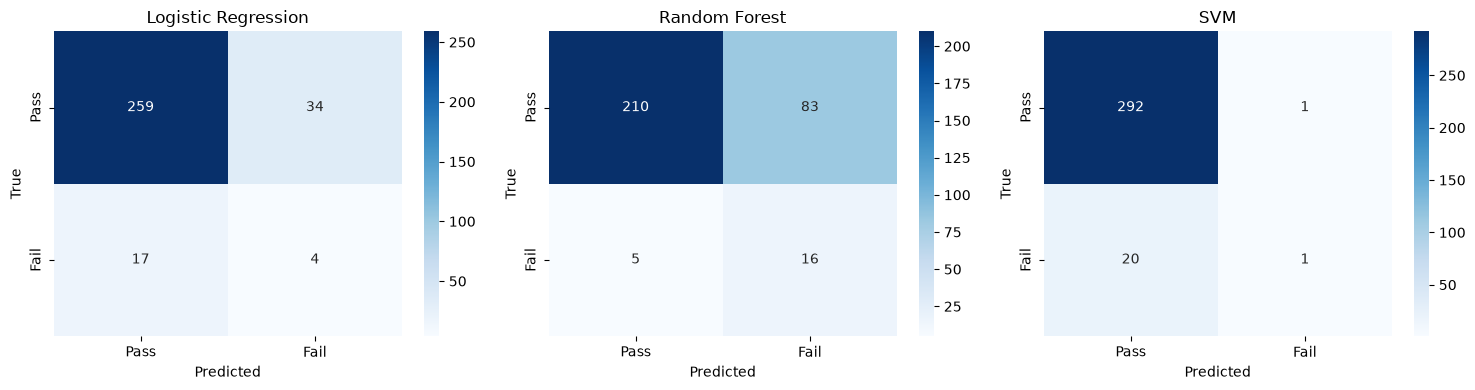

In [ ]:
#  Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, (name, info) in zip(axes, final_results.items()):
    cm = confusion_matrix(y_test, info['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=['Pass','Fail'], yticklabels=['Pass','Fail'])
    ax.set_title(name); ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.tight_layout(); plt.show()

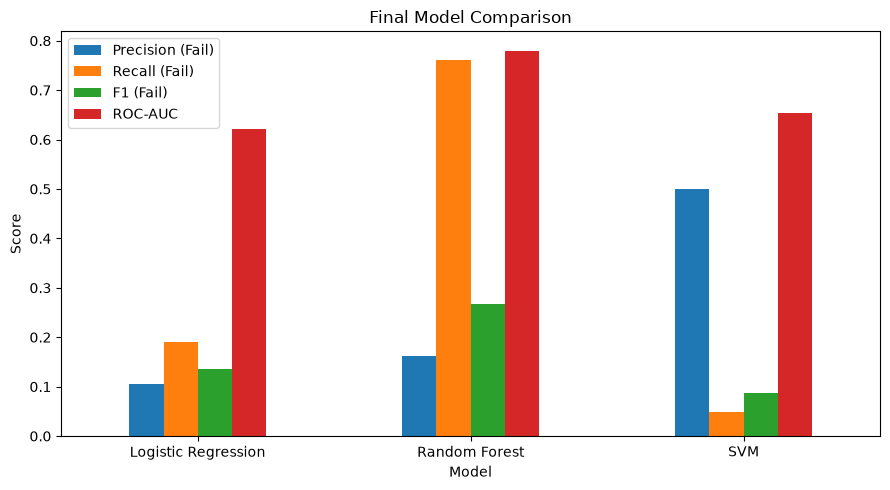

In [ ]:
# compare by graphs 
summary_df.set_index('Model')[['Precision (Fail)','Recall (Fail)','F1 (Fail)','ROC-AUC']].plot(kind='bar', figsize=(9,5))
plt.title('Final Model Comparison'); plt.ylabel('Score'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()


In [ ]:
# the best model 
best = summary_df.loc[summary_df['F1 (Fail)'].idxmax(),'Model']
print("\nBest model:", best)


Best model: Random Forest
